# Full Notebook Structure

# Task 2: Credit Risk Prediction

**Objective:**  
Predict whether a loan applicant is likely to default on a loan (Binary Classification Problem).

**Dataset:** Loan Prediction Dataset (Kaggle)

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load Dataset

In [2]:
# Load the training data
train = pd.read_csv('loan_train.csv')   # apna file naam yahan daal do

print("Dataset Shape:", train.shape)
train.head()

Dataset Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# Basic Dataset Understanding

In [3]:
# Basic Information
print("Dataset Shape:", train.shape)
print("\nColumns:", train.columns.tolist())

Dataset Shape: (614, 13)

Columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [4]:
# Data Types aur Missing Values
print("\nDataset Info:")
train.info()

# Missing Values Check
print("\nMissing Values:")
print(train.isnull().sum())

# Percentage of missing values
print("\nMissing Values Percentage:")
print((train.isnull().sum() / len(train) * 100).round(2))


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB

Missing Values:
Loan_ID               0
Gender               13
Married               3
Dependen

In [5]:
# Target Variable Distribution
print("\nLoan Status Distribution:")
print(train['Loan_Status'].value_counts())
print("\nPercentage:")
print(train['Loan_Status'].value_counts(normalize=True) * 100)


Loan Status Distribution:
Loan_Status
Y    422
N    192
Name: count, dtype: int64

Percentage:
Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64


# Handling Missing Values

In [6]:
# Create a working copy of the dataset
df = train.copy()

# 1. Fill Missing Values in Categorical Columns using Mode (most frequent value)
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

# 2. Fill Missing Values in Numerical Columns using Median
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

# Check missing values after handling
print("=== Missing Values After Handling ===")
print(df.isnull().sum())

=== Missing Values After Handling ===
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


# Exploratory Data Analysis (EDA) & Visualizations

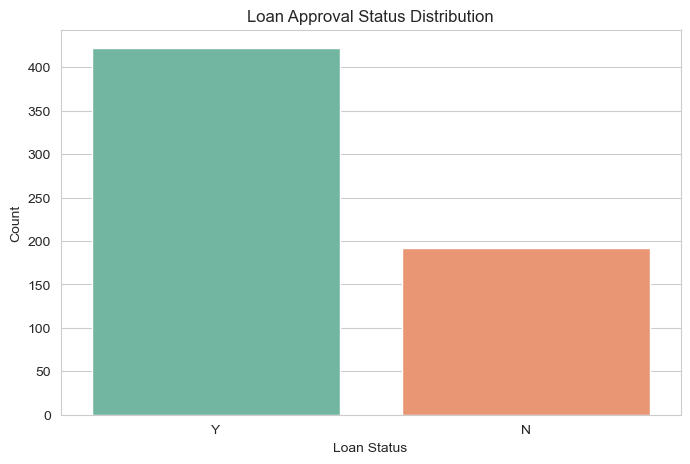

In [7]:
# 1. Target Variable Distribution (Already done, but visualizing)
plt.figure(figsize=(8, 5))
sns.countplot(x='Loan_Status', data=df, palette='Set2')
plt.title('Loan Approval Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

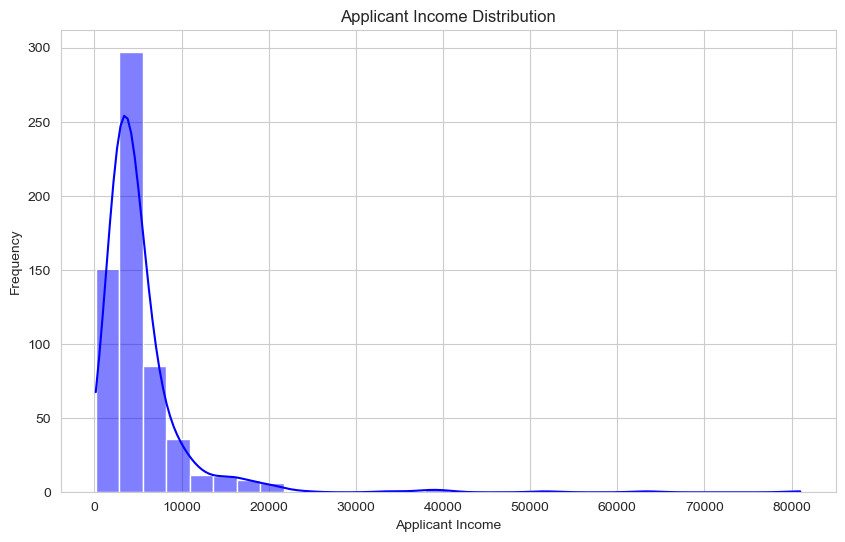

In [8]:
# 2. Applicant Income Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['ApplicantIncome'], kde=True, bins=30, color='blue')
plt.title('Applicant Income Distribution')
plt.xlabel('Applicant Income')
plt.ylabel('Frequency')
plt.show()

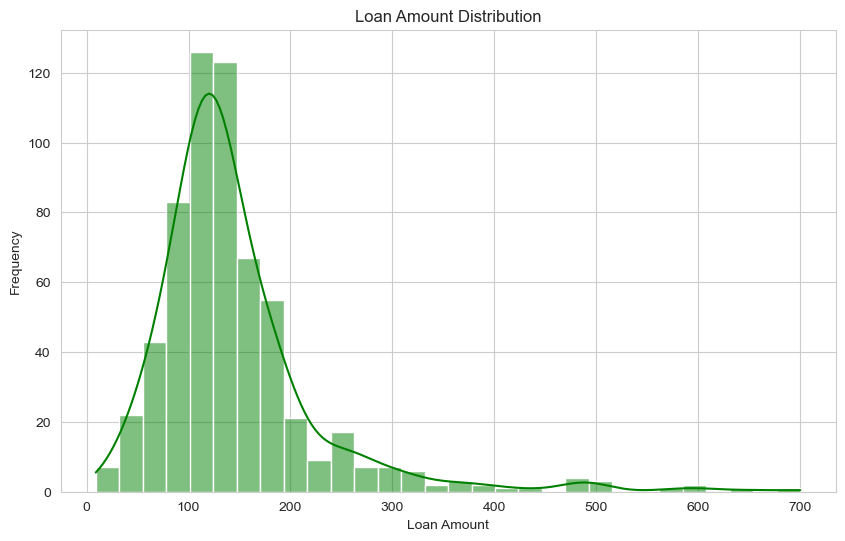

In [9]:
# 3. Loan Amount Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['LoanAmount'], kde=True, bins=30, color='green')
plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()

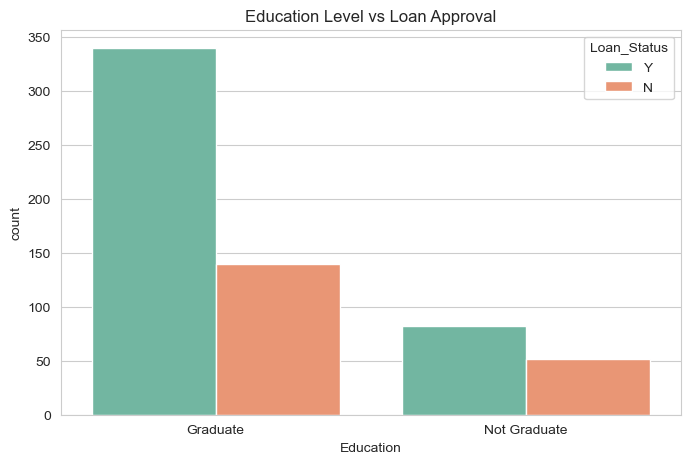

In [10]:
# 4. Education vs Loan Status
plt.figure(figsize=(8, 5))
sns.countplot(x='Education', hue='Loan_Status', data=df, palette='Set2')
plt.title('Education Level vs Loan Approval')
plt.show()

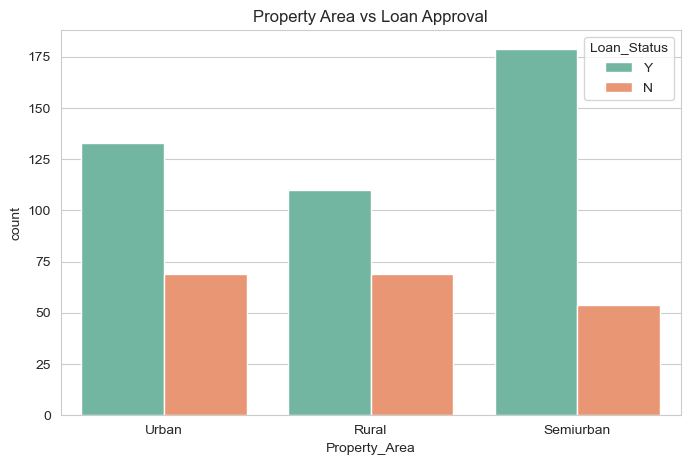

In [11]:
# 5. Property Area vs Loan Status
plt.figure(figsize=(8, 5))
sns.countplot(x='Property_Area', hue='Loan_Status', data=df, palette='Set2')
plt.title('Property Area vs Loan Approval')
plt.show()

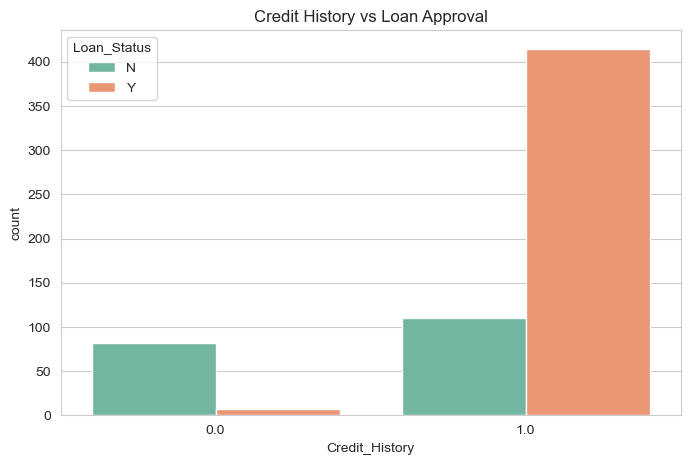

In [12]:
# 6. Credit History vs Loan Status (Very Important Feature)
plt.figure(figsize=(8, 5))
sns.countplot(x='Credit_History', hue='Loan_Status', data=df, palette='Set2')
plt.title('Credit History vs Loan Approval')
plt.show()

# Feature Encoding

In [16]:
# Create a copy for modeling
df_model = df.copy()

# Label Encoding for binary columns
from sklearn.preprocessing import LabelEncoder
label_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Loan_Status']
le = LabelEncoder()

for col in label_cols:
    df_model[col] = le.fit_transform(df_model[col])

# One-Hot Encoding
df_model = pd.get_dummies(df_model, columns=['Property_Area', 'Dependents'], drop_first=True)

# Drop Loan_ID
df_model = df_model.drop('Loan_ID', axis=1)

print("Encoding Done!")
print("Shape:", df_model.shape)
print("Columns:", df_model.columns.tolist())

Encoding Done!
Shape: (614, 15)
Columns: ['Gender', 'Married', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Loan_Status', 'Property_Area_Semiurban', 'Property_Area_Urban', 'Dependents_1', 'Dependents_2', 'Dependents_3+']


# Train-Test Split + Model Training

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Separate Features (X) and Target (y)
X = df_model.drop('Loan_Status', axis=1)
y = df_model['Loan_Status']

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (491, 14)
Testing Data Shape: (123, 14)


 # Model 1: Logistic Regression

In [19]:
log_model = LogisticRegression(max_iter=500)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("\n=== Logistic Regression Results ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_log), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))


=== Logistic Regression Results ===
Accuracy: 0.7886

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



# Model 2: Decision Tree

In [20]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("\n=== Decision Tree Results ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_dt), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))


=== Decision Tree Results ===
Accuracy: 0.7561

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.42      0.55        43
           1       0.75      0.94      0.83        80

    accuracy                           0.76       123
   macro avg       0.77      0.68      0.69       123
weighted avg       0.76      0.76      0.73       123



# Confusion Matrix Visualization

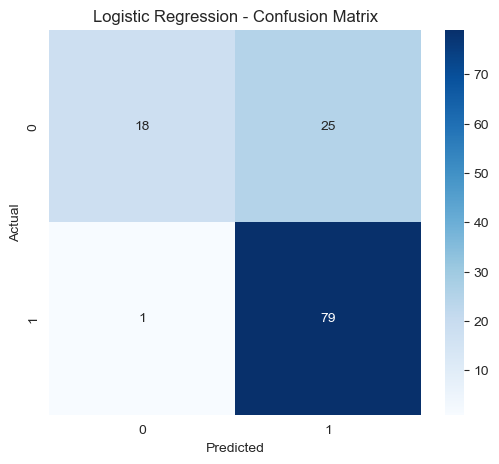

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Logistic Regression Confusion Matrix
plt.figure(figsize=(6, 5))
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

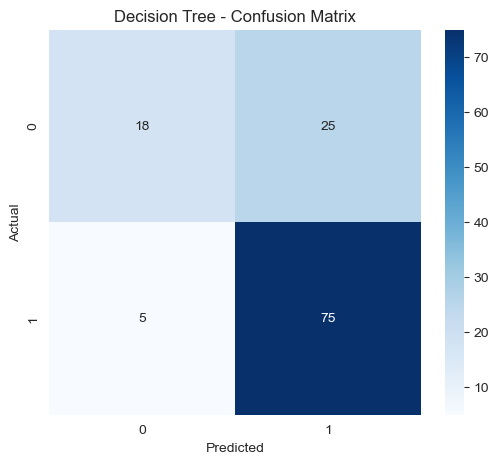

In [22]:
# Decision Tree Confusion Matrix
plt.figure(figsize=(6, 5))
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Conclusion & Key Insights

## Task Summary
- Successfully performed Credit Risk Prediction using Loan Prediction Dataset.
- Handled missing values using Mode (categorical) and Median (numerical).
- Performed Exploratory Data Analysis with multiple visualizations.
- Trained two classification models: **Logistic Regression** and **Decision Tree**.

## Model Performance
- **Logistic Regression**: Accuracy = **78.86%**
- **Decision Tree**: Accuracy = **75.61%**

## Key Business Insights
- `Credit_History` is the most important feature for loan approval.
- Applicants with good credit history have much higher chances of loan approval.
- Graduate applicants have better approval rate compared to Under-Graduate.
- Semiurban property area shows higher approval rate.
- Income level and Loan Amount also play important roles in decision making.

## Challenges Faced
- Dataset was slightly imbalanced (68.7% approved loans).
- Missing values were present in multiple columns.

## Skills Applied
- Data Cleaning & Missing Value Handling
- Exploratory Data Analysis (EDA)
- Feature Encoding (Label + One-Hot)
- Binary Classification Modeling
- Model Evaluation using Accuracy and Confusion Matrix

**This notebook fulfills all the requirements mentioned in Task 2.**